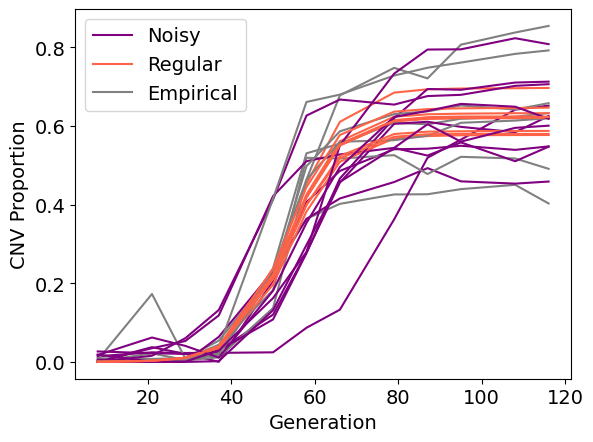

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, wrapper_hierarchical, WF
import warnings
warnings.simplefilter('ignore', FutureWarning)

generation = np.array(pd.read_csv('empirical_data/Chuong_116_gens.txt').columns.astype('int'))

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

th = torch.tensor([-0.74,-4.84,-4.32], dtype=torch.float32)
X = wrapper(WF, parameters=th, reps=10) # LTRΔ MAP in paper
X_emp = torch.from_numpy(np.array(pd.read_csv('empirical_data/ltr.csv', index_col=0)))
X_h = wrapper_hierarchical(WF, parameters=th, reps=10, var=0.1)
X_h = X_h + torch.normal(0,0.02, size=X_h.shape)
X_h = X_h.clamp(0,1)
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X_h[i], color='purple', label='Noisy' if i==0 else '', lw=1.5)
    plt.plot(generation,X[i], color='tomato', label='Regular' if i==0 else '', lw=1.5)
    if i < len(X_emp):
        plt.plot(generation,X_emp[i], color='grey', label='Empirical' if i==0 else '', lw=1.5)
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')
plt.legend()

Evaluating 100000 samples: 100%|██████████| 10/10 [00:01<00:00,  8.64it/s]


CPU times: user 54.1 s, sys: 3.49 s, total: 57.6 s
Wall time: 1.29 s


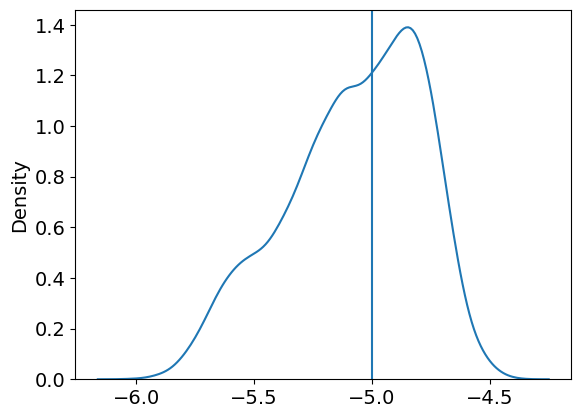

In [5]:
%%time
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl', 'rb'))
th = torch.tensor([-0.7,-5,-4.5])
Xs = wrapper(WF, parameters=th, reps=10)
op = CollectivePosterior(prior, Xs, posterior_chuong, 1, epsilon=-10, n_eval=100000)
# op.get_log_C()
# mcmc_samples = op.sample(1000)
# rej_samples = op.rejection_sample(1000)
samples = op.sample_via_sir_jitter()
p = 1
kdeplot(samples[:,p])
# kdeplot(samples_n[:,p])
# kdeplot(rej_samples[:,p])
# kdeplot(mcmc_samples[:,p])
plt.axvline(th[p].item())

Text(0, 0.5, '')

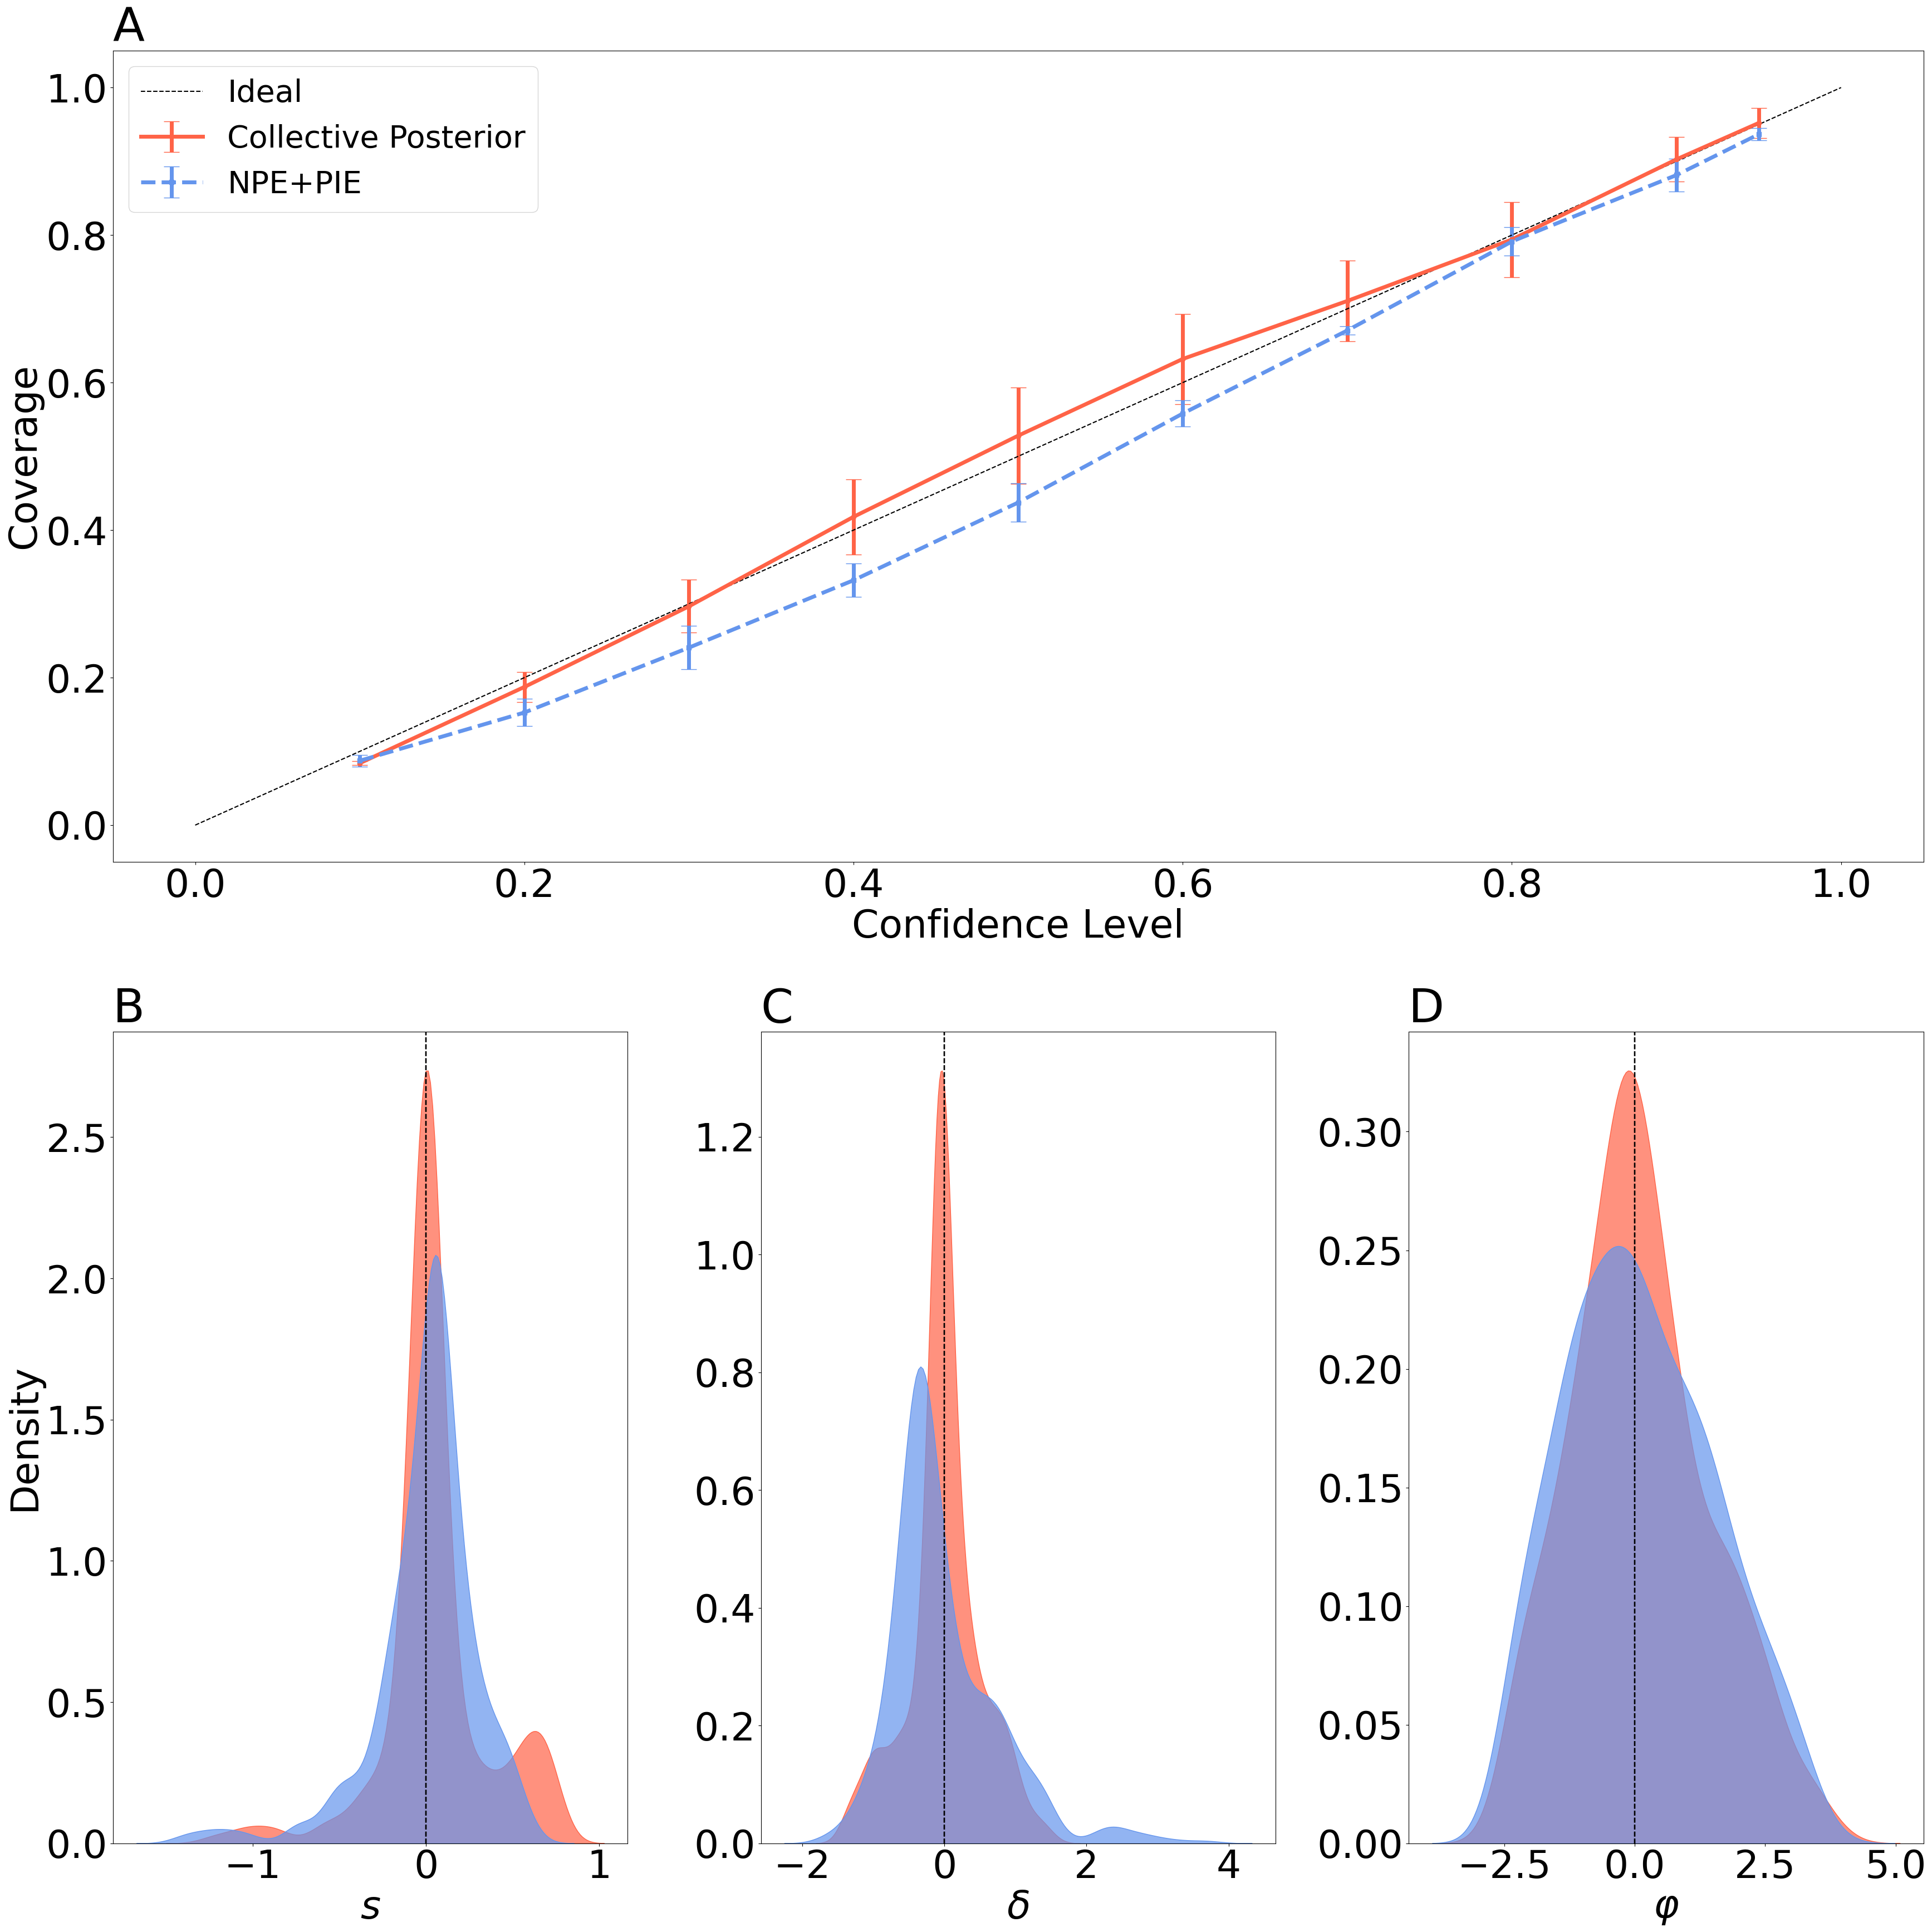

In [2]:
change_font(50)

# plot accuracy in 2X3 axis
def plot_accuracy(acc, ax, color, label, hatch):
    parameters = ['$s$', '$\\delta$', '$\\varphi$']
    for i in range(len(ax)):

        kdeplot(acc[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
        ax[i].set_xlabel(parameters[i])
    return

conf_levels = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95], dtype=float)
def plot_covs(ax, covs1, covs2):
    """
    Plot mean coverage across parameters (and repeats) with error bars showing
    variability among parameters.

    Expects covs arrays of shape (n_repeats, n_conf, n_params) or (n_conf, n_params).
    """
    import numpy as np

    def to_np(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    a1 = to_np(covs1)
    a2 = to_np(covs2)

    # normalize shapes to (n_repeats, n_conf, n_params)
    if a1.ndim == 2:
        a1 = a1[None, ...]
    if a2.ndim == 2:
        a2 = a2[None, ...]

    n_reps, n_conf, n_params = a1.shape

    # For each confidence level, compute per-parameter mean across repeats,
    # then compute the mean across parameters (value to plot) and the std across parameters
    mean1 = np.empty(n_conf)
    sd1 = np.empty(n_conf)
    mean2 = np.empty(n_conf)
    sd2 = np.empty(n_conf)

    for j in range(n_conf):
        # shape (n_reps, n_params) -> mean over repeats -> (n_params,)
        per_param_mean1 = a1[:, j, :].mean(axis=0)
        per_param_mean2 = a2[:, j, :].mean(axis=0)
        # mean across parameters
        mean1[j] = per_param_mean1.mean()
        mean2[j] = per_param_mean2.mean()
        # variability among parameters (std). Use std (not se) as requested.
        sd1[j] = per_param_mean1.std(ddof=0)
        sd2[j] = per_param_mean2.std(ddof=0)

    palette = {'Collective Posterior': 'tomato', 'NPE+PIE': 'cornflowerblue'}

    ax.errorbar(conf_levels, mean1, yerr=sd1, label='Collective Posterior',
                color=palette['Collective Posterior'], marker='o', linestyle='-', capsize=10, linewidth=5)
    ax.errorbar(conf_levels, mean2, yerr=sd2, label='NPE+PIE',
                color=palette['NPE+PIE'], marker='s', linestyle='--', capsize=10, linewidth=5)
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='k', linestyle='--', label='Ideal')
    ax.legend(fontsize=40)


# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AAA
            BCD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

# Coverage plots in ax A
covs = torch.load(f'covs_WF_imp.pt')
covs_iid = torch.load(f'covs_WF_iid.pt')
plot_covs(ax=ax['A'], covs1=covs, covs2=covs_iid)
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D']]

cp_acc = torch.load('accus_WF_imp.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('accus_WF_iid.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['C'].set_ylabel('')
ax['D'].set_ylabel('')
